<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

In [3]:
crop_dfs = []
for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    # tmp = tmp.copy()
    # tmp['Year'] = tmp['Year'].astype(int)
    # tmp['crop_type'] = crop_name
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True, axis=0)
print(f"Loaded crop_df shape: {crop_df.shape}")

Loaded crop_df shape: (8526, 18)


In [4]:
# Keep only Yield rows (FAOSTAT typically also has 'Area harvested' and 'Production' as Elements)
print("Elements before filtering:", crop_df['Element'].unique())

crop_df = crop_df[crop_df['Element'].str.contains('Yield', case=False, na=False)]

print("Crop data shape after keeping only Yield rows:", crop_df.shape)
print("Elements after filtering:", crop_df['Element'].unique())

Elements before filtering: ['Area harvested' 'Yield' 'Production']
Crop data shape after keeping only Yield rows: (2842, 18)
Elements after filtering: ['Yield']


In [5]:
# Check for basic data quality
print("\n=== Data Quality Checks ===")
print(f"Total rows: {len(crop_df)}")
print(f"Null values per column:")
print(crop_df.isnull().sum())
print(f"\nDataFrame info:")
print(crop_df.info())

# Check unique values in key columns
print(f"\nUnique crops: {crop_df['Item'].nunique() if 'Item' in crop_df.columns else 'Item column not found'}")
print(f"Year range: {crop_df['Year'].min() if 'Year' in crop_df.columns else 'Year column not found'} - {crop_df['Year'].max() if 'Year' in crop_df.columns else 'Year column not found'}")


=== Data Quality Checks ===
Total rows: 2842
Null values per column:
Domain Code             0
Domain                  0
Area Code (FAO)         0
Area                    0
Element Code            0
Element                 0
Item Code (FAO)         0
Item                    0
Year Code               0
Year                    0
Unit                    0
Value                   0
Flag                    0
Flag Description        0
Nitrogen (N) kg/ha      0
Phosphorus (P) kg/ha    0
Potassium (K) kg/ha     0
crop_type               0
dtype: int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 2842 entries, 58 to 8467
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Domain Code           2842 non-null   object 
 1   Domain                2842 non-null   object 
 2   Area Code (FAO)       2842 non-null   int64  
 3   Area                  2842 non-null   object 
 4   Element Code      

In [6]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

In [7]:
for dfc in (rainfall, temperature):
    if 'YEAR' in dfc.columns:
        dfc.rename(columns={'YEAR': 'Year'}, inplace=True)
    if 'Year' not in dfc.columns:
        raise ValueError("Climate files must have a 'Year' column")

In [8]:

climate_df = pd.merge(rainfall, temperature, on='Year', how='outer')
merged_df = pd.merge(climate_df, crop_df, on='Year', how='outer')

# Or in one line
# merged_df = pd.merge(pd.merge(df1, df2, on='Year', how='outer'), df3, on='Year', how='outer')

In [9]:
# compute seasonal aggregates if not present
if 'winter_avg' not in climate_df.columns:
    # winter defined here as DEC (prev), JAN, FEB — approximation using available DEC/JAN/FEB
    # Because DEC previous-year isn't directly available per-row, we compute seasonal proxies as mean of DJF where available
    climate_df['winter_avg'] = climate_df[['DEC', 'JAN', 'FEB']].mean(axis=1)
if 'summer_avg' not in climate_df.columns:
    climate_df['summer_avg'] = climate_df[['MAR', 'APR', 'MAY']].mean(axis=1)
if 'monsoon_avg' not in climate_df.columns:
    climate_df['monsoon_avg'] = climate_df[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1)

climate_df['climate_std'] = climate_df[['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']].std(axis=1)

print("Climate preprocessing done.")

Climate preprocessing done.


In [10]:
climate_df.drop('ANN', axis=1, inplace=True)

In [11]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     floa

In [12]:
climate_df_clean = climate_df_clean.drop(
    columns=['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
)

In [13]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,10.4,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,29.9,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,15.5,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,13.3,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,22.2,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,16.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,56.1,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,12.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,12.7,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,1.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596


#Correlation-Based Feature Selection


Number of climate features: 20
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


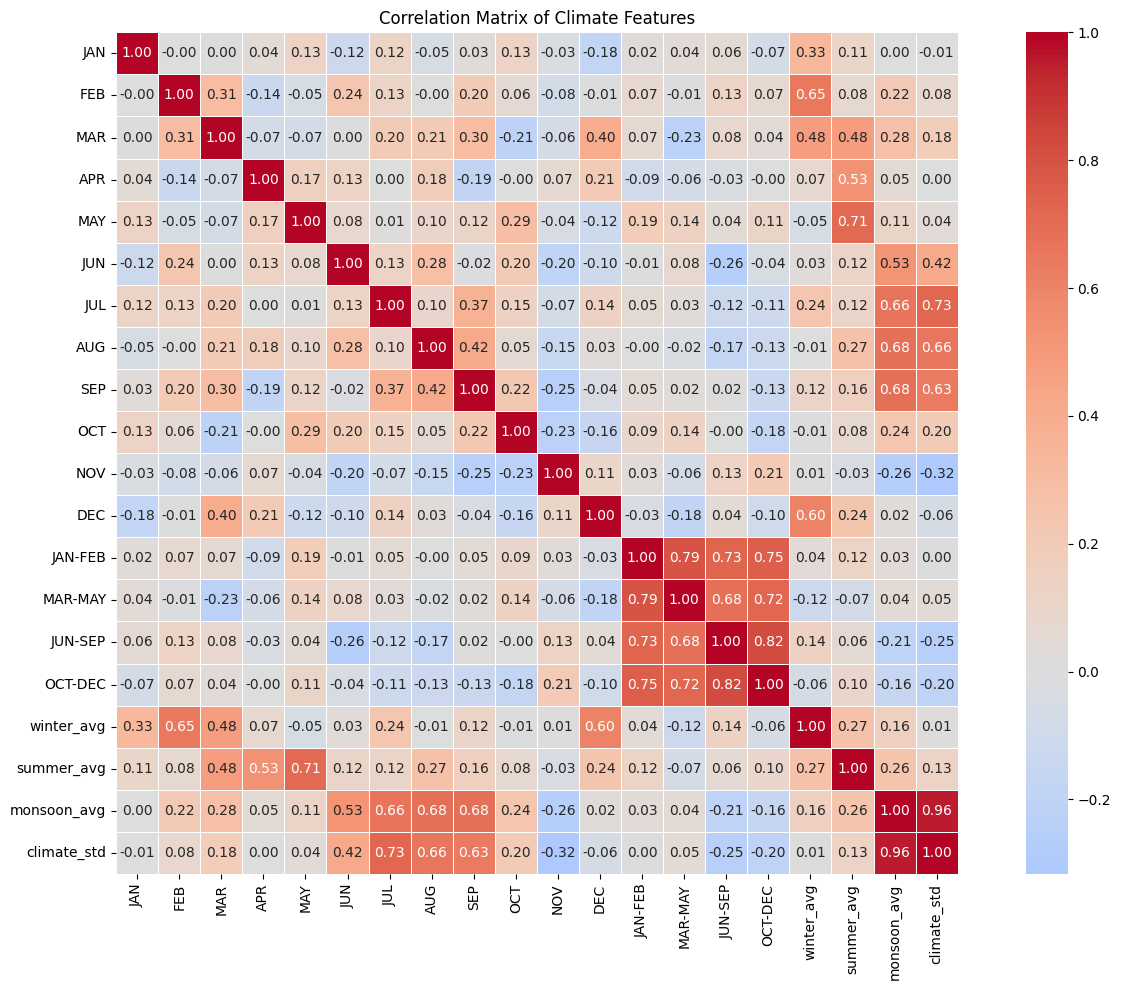


Highly correlated feature pairs (|corr| > 0.85):
     Feature 1    Feature 2  Correlation
0  monsoon_avg  climate_std     0.958369


In [14]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

In [15]:
# Strategy: Keep the feature with higher variance or better interpretability
def handle_correlated_features(df, corr_threshold=0.85):
    """
    Remove highly correlated features, keeping the one with higher variance
    """
    # Calculate variance for each numeric feature
    variances = df.select_dtypes(include=[np.number]).var()

    # Get correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Find pairs with correlation above threshold
    features_to_drop = set()
    correlated_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > corr_threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                correlated_pairs.append((feat1, feat2))

                # Keep the feature with higher variance
                if variances[feat1] >= variances[feat2]:
                    features_to_drop.add(feat2)
                else:
                    features_to_drop.add(feat1)

    return features_to_drop, correlated_pairs

In [16]:
# Apply the correlation handling
features_to_drop, correlated_pairs = handle_correlated_features(
    climate_df_clean,
    corr_threshold=0.85
)

print("\nFeatures to drop due to high correlation:")
print(features_to_drop)


Features to drop due to high correlation:
{'climate_std'}


In [17]:
# Create a clean dataset without these features
climate_reduced = climate_df_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nOriginal features: {len(climate_df_clean.columns)}")
print(f"Features after removing correlated: {len(climate_reduced.columns)}")
print(f"Remaining features: {climate_reduced.columns.tolist()}")


Original features: 22
Features after removing correlated: 21
Remaining features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']


In [18]:
# ===================== 2. UPDATED FEATURE LIST =====================

# Get the remaining features (excluding Year and ANNUAL)
feature_cols = [col for col in climate_reduced.columns
                if col not in ['Year', 'ANNUAL']]

print(f"\nFeatures for analysis: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")


Features for analysis: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']
Number of features: 19


In [22]:
feature_cols

['JAN',
 'FEB',
 'MAR',
 'APR',
 'MAY',
 'JUN',
 'JUL',
 'AUG',
 'SEP',
 'OCT',
 'NOV',
 'DEC',
 'JAN-FEB',
 'MAR-MAY',
 'JUN-SEP',
 'OCT-DEC',
 'winter_avg',
 'summer_avg',
 'monsoon_avg']

In [20]:
# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")


Crop data:
    Year    Item Element  Value crop_type  Nitrogen (N) kg/ha  \
58  1965  Apples   Yield  41573    apples               46.33   
59  1966  Apples   Yield  41558    apples               85.55   
60  1967  Apples   Yield  41543    apples               94.41   
61  1968  Apples   Yield  41509    apples               77.99   
62  1969  Apples   Yield  41475    apples              156.02   

    Phosphorus (P) kg/ha  Potassium (K) kg/ha  
58                 50.38                45.03  
59                 44.48                10.98  
60                 23.67                91.48  
61                 60.57                18.22  
62                 29.65                38.74  
Shape: (2842, 8)


In [26]:
# F-score selected features (from your output)
# fscore_selected_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
# print(f"F-score selected features: {fscore_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_fscore = climate_df_clean[['Year'] + feature_cols].copy()


print("\nClimate data with Correlation selected features:")
print(climate_fscore.head())
print(f"Shape: {climate_fscore.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH F-SCORE FEATURES =====================

# Merge crop data with F-score selected climate features
merged_corr_data = pd.merge(
    crop_data_clean,
    climate_fscore,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + F-score selected features):")
print(merged_corr_data.head())
print(f"Shape: {merged_corr_data.shape}")
print(f"Columns: {merged_corr_data.columns.tolist()}")



Climate data with Correlation selected features:
   Year   JAN   FEB   MAR   APR   MAY    JUN    JUL    AUG    SEP    OCT  \
0  1961  26.1  34.8  26.0  28.5  77.6  192.9  336.6  287.6  234.9  122.2   
1  1962  12.6  21.6  16.0  43.6  70.8  137.1  281.6  276.9  211.0   78.4   
2  1963   6.8   9.8  41.7  50.6  60.9  168.0  258.6  316.7  164.9   99.1   
3  1964  18.6  14.1  19.0  40.0  52.1  177.2  345.7  273.7  200.4   67.4   
4  1965  11.8  28.1  26.7  45.1  52.7  116.1  270.1  192.8  129.5   34.0   

    NOV   DEC  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  winter_avg  summer_avg  \
0  21.7  10.4    18.98    26.11    27.06    21.17   23.766667   44.033333   
1  18.3  29.9    18.91    25.91    27.14    21.47   21.366667   43.466667   
2  28.4  15.5    19.07    25.57    27.21    22.04   10.700000   51.066667   
3  22.8  13.3    18.83    26.38    26.90    21.58   15.333333   37.033333   
4  18.2  22.2    19.22    25.24    27.08    22.10   20.700000   41.500000   

   monsoon_avg  
0      263.00

In [27]:
# ===================== 3. SAVE MERGED DATASET =====================

# Save the merged dataset
merged_corr_data.to_csv('crop_corr_merged_data.csv', index=False)
print("\n✅ Merged dataset saved to 'crop_corr_merged_data.csv'")


✅ Merged dataset saved to 'crop_corr_merged_data.csv'



CORRELATION ANALYSIS WITH F-SCORE FEATURES

Correlation with crop yield (Value):
Value          1.000000
JUN-SEP        0.095397
OCT-DEC        0.094843
MAR-MAY        0.090755
JAN-FEB        0.087231
SEP            0.019539
OCT            0.015347
FEB            0.007662
MAY            0.002225
monsoon_avg    0.000941
JUN           -0.002491
JUL           -0.004651
APR           -0.005712
summer_avg    -0.007991
AUG           -0.008207
JAN           -0.008883
MAR           -0.012338
NOV           -0.012692
winter_avg    -0.013206
DEC           -0.020156
Name: Value, dtype: float64


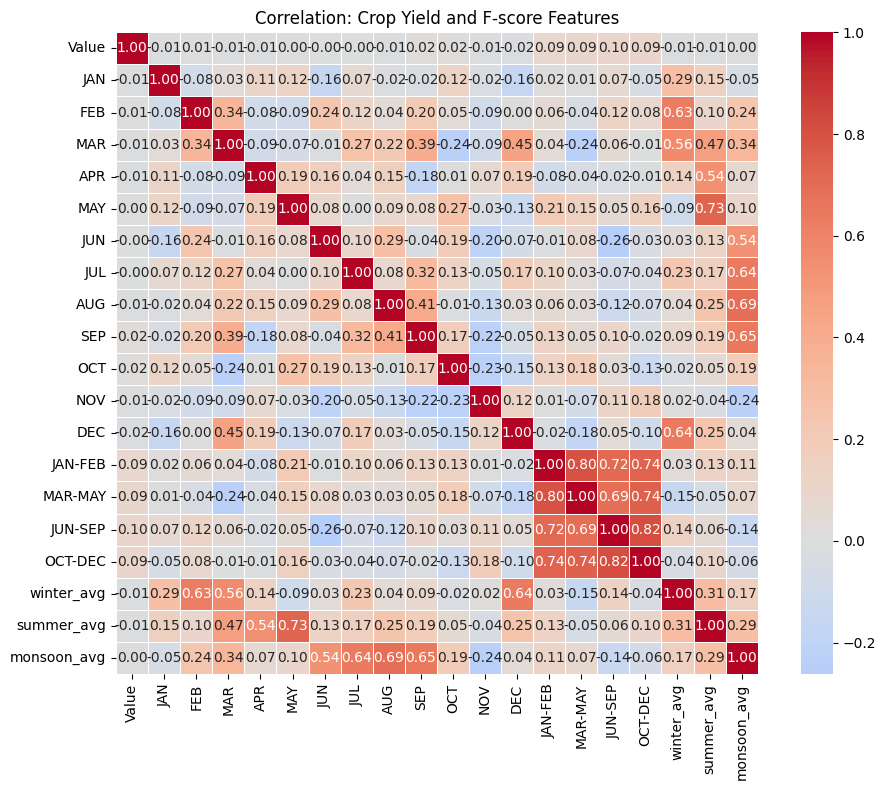

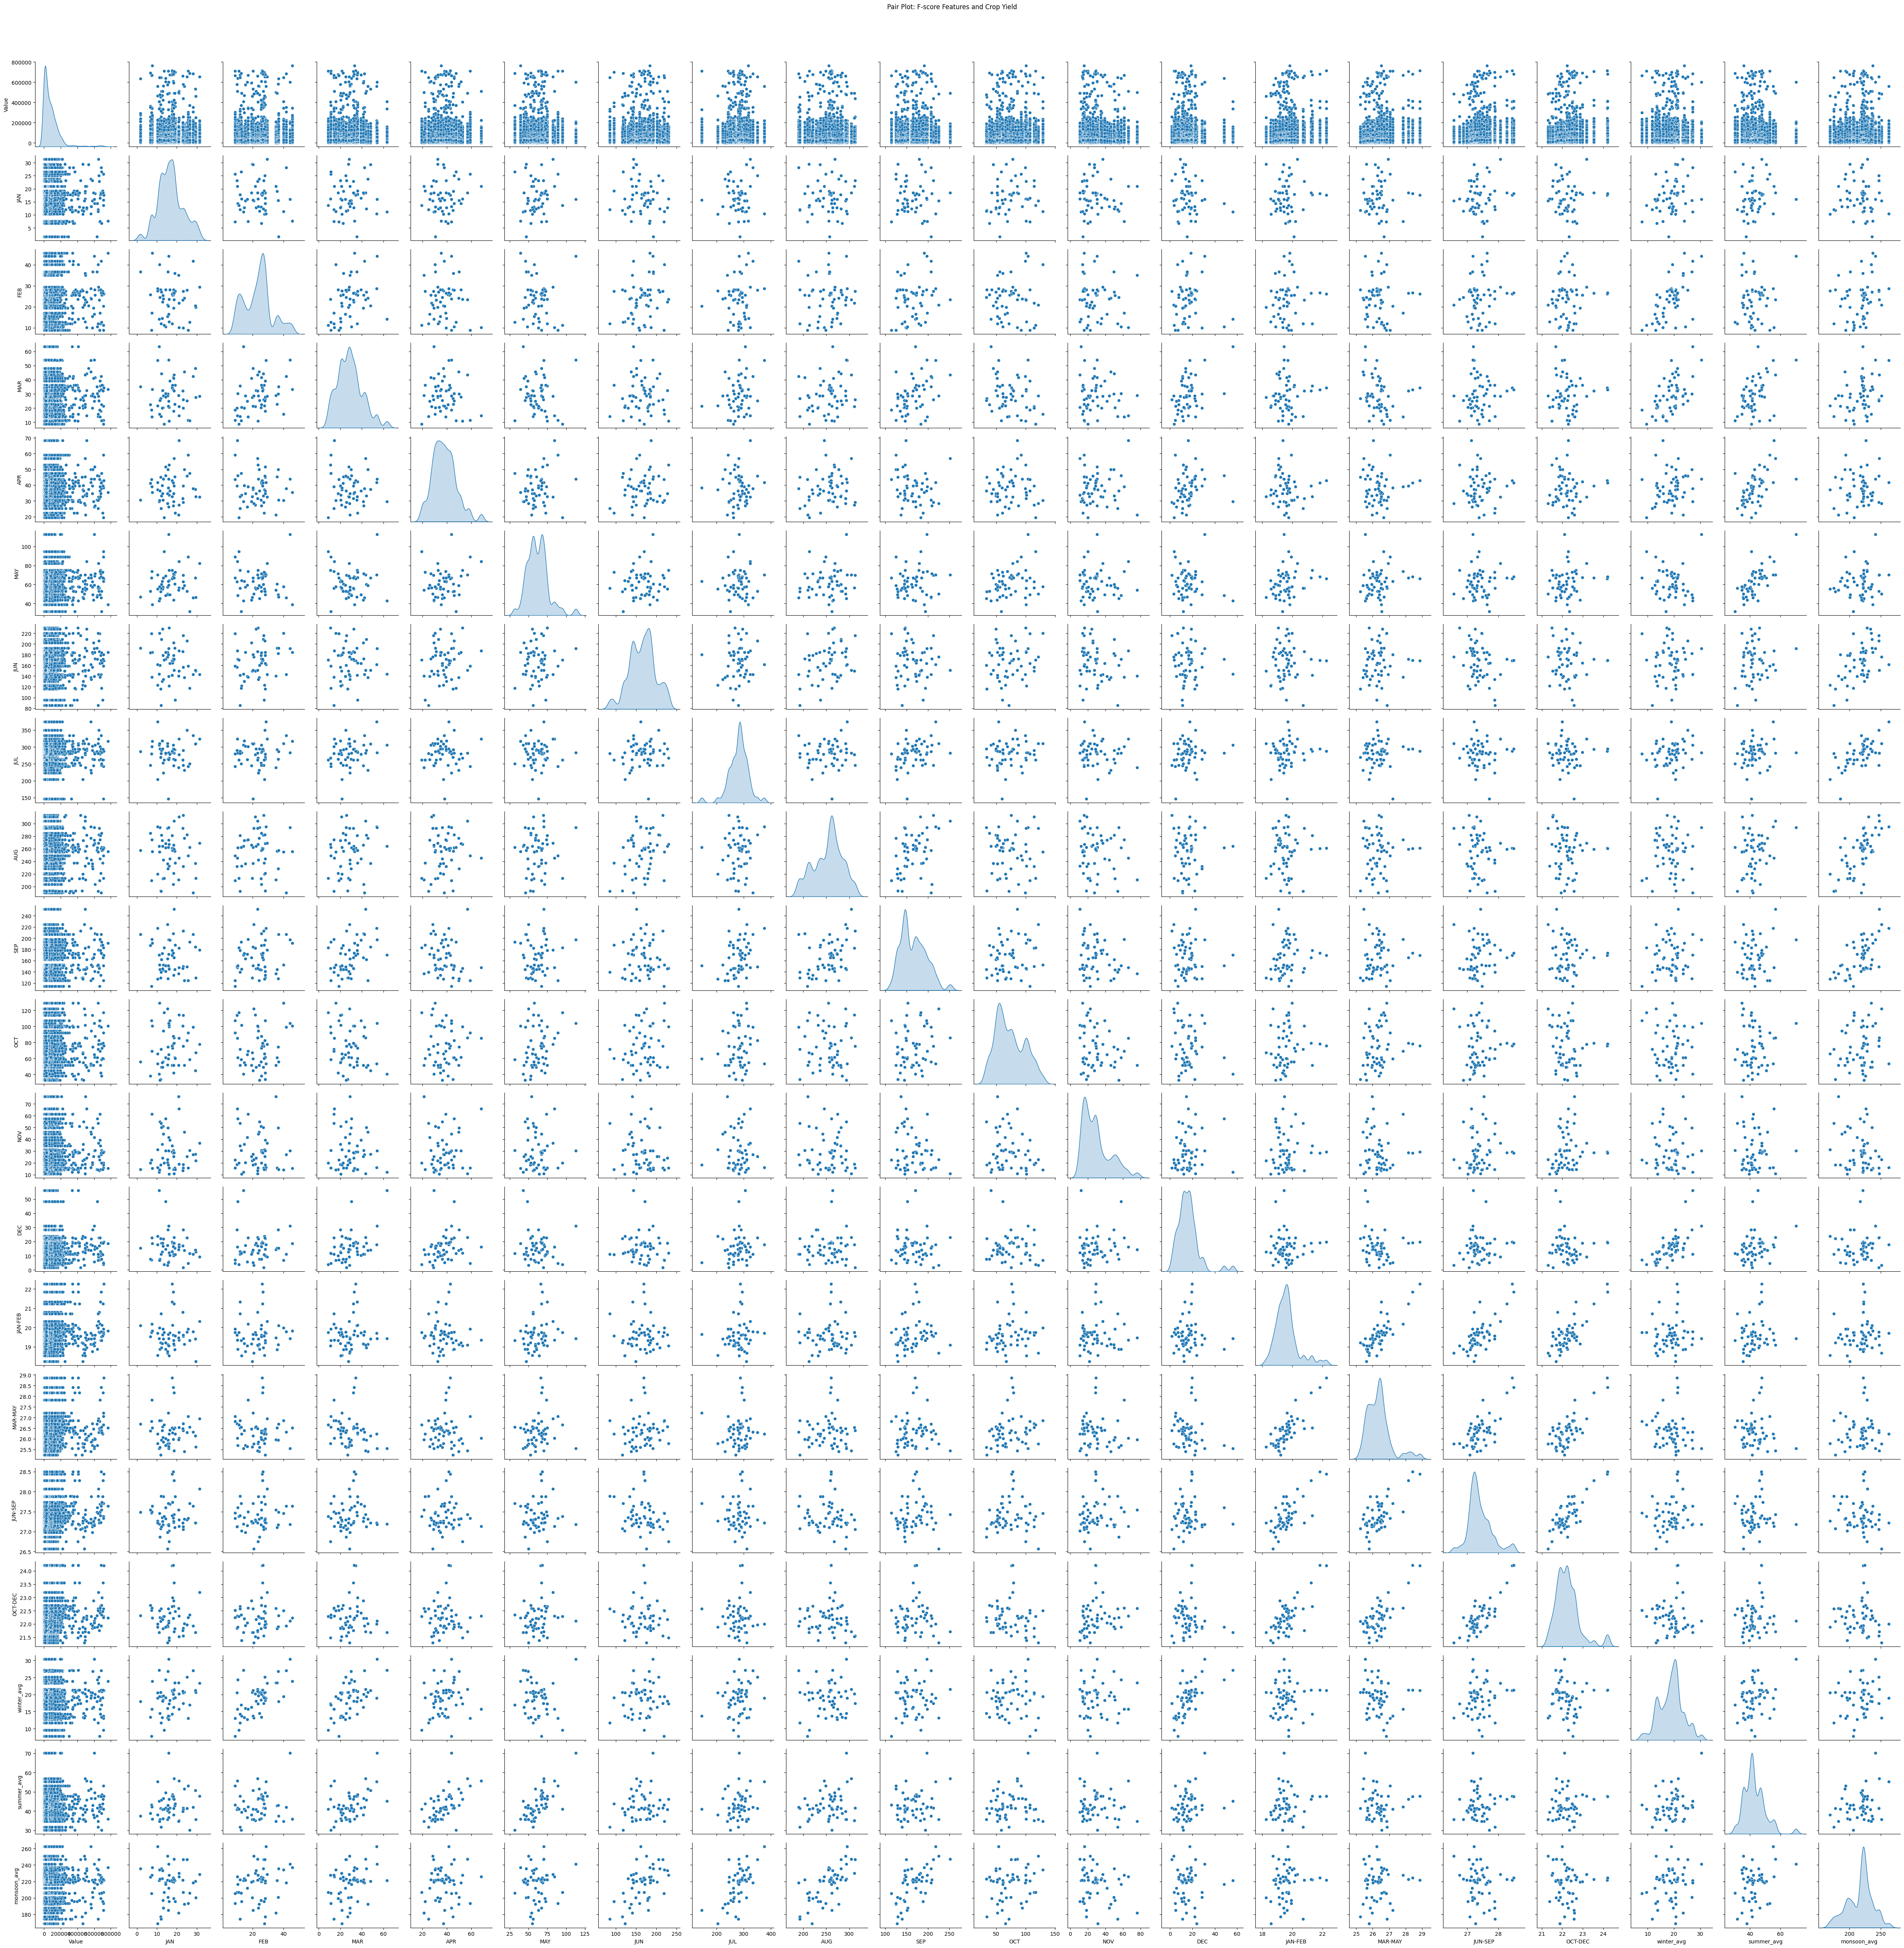

In [28]:
# ===================== 4. CORRELATION ANALYSIS =====================

print("\n" + "="*60)
print("CORRELATION ANALYSIS WITH F-SCORE FEATURES")
print("="*60)

# Correlation between F-score features and crop yield
correlation_matrix = merged_corr_data[['Value'] + feature_cols].corr()
print("\nCorrelation with crop yield (Value):")
print(correlation_matrix['Value'].sort_values(ascending=False))

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation: Crop Yield Features')
plt.tight_layout()
plt.show()

# Pair plot of selected features
sns.pairplot(merged_corr_data[['Value'] + feature_cols],
             diag_kind='kde', height=2.5)
plt.suptitle('Pair Plot: F-score Features and Crop Yield', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + F-score features)
# merged_data = pd.read_csv('crop_fscore_merged_data.csv')

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Columns: {merged_data.columns.tolist()}")
print("\nFirst 5 rows:")
# print(merged_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
# fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
print(f"\nFeatures used for clustering: {feature_cols}")

# Extract feature matrix
X = crop_data[feature_cols].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET


NameError: name 'merged_data' is not defined